# PEC4. Artificial Neural Networks

Las Redes Neuronales Artificiales imitan la estructura del cerebro humano para poder procesar información y resolver todo tipo de problemas complejos.

Como algoritmo de clasificación, destaca su capacidad de manejar problemas multiclase y con variables independientes. Además,  entre sus ventajas se incluyen su flexibilidad, la adaptabilidad a los datos y la precisión de sus clasificaciones.

Aún así, una de sus principales desventajas son su alta demanda computacional, su dependencia a la calidad de los datos y la dificultad de interpetar sus resultados. Además de su demanda copmutacional, la creación de algoritmos de ANN tiene cierta dependencia a Python, ya que los paquetes necesarios están formulados en dicho lenguaje.

Para poder crear el algoritmo, tendremos que conectar el servidor de Google Drive  a través del a función drive.amount del paquete `google.colab`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

Una vez disponemos de nuestros ficheros, usaremos el paquete `pandas`.  Para poder cargar el dataset *mushroom*, estableceremos la ubicación del documento csv (file_path), y lo cargaremos con la función `pd.read_csv()`. Del mismo modo que en R, en Python podemos visualizar los primeros registros del data set  con `data.head()`.

In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/mushroom_small.csv'

# Cargar el archivo CSV
data = pd.read_csv(file_path)

# Ver las primeras filas del DataFrame
data.head()
data.describe()


,cap.diameter,cap.shape,gill.attachment,gill.color,stem.height,stem.width,stem.color,season,class
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,571.014600,4.021300,2.162300,7.352600,0.761234,1056.209800,8.443200,0.954216,0.549000
std,360.863365,2.157664,2.233665,3.185387,0.658917,787.389461,3.260803,0.303873,0.497618
min,2.000000,0.000000,0.000000,0.000000,0.000426,0.000000,0.000000,0.027372,0.000000
25%,292.750000,2.000000,0.000000,5.000000,0.270146,417.000000,6.000000,0.888450,0.000000
50%,526.000000,5.000000,1.000000,8.000000,0.597274,923.000000,11.000000,0.943195,1.000000
75%,787.000000,6.000000,4.000000,10.000000,1.054858,1529.000000,11.000000,0.943195,1.000000
max,1890.000000,6.000000,6.000000,11.000000,3.835320,3569.000000,12.000000,1.804273,1.000000


##  Exploración de los datos

Los datos cargados contienen tanto datos categóricos como numéricos.
Como tratamos con muchos datos y muchas variables, apreciar posibles relaciones (ya sean positivas o negativas) puede resultar complicado. Para poder analizar las relaciones más gráficamente, seleccionaremos las columnas numéricas (float y int) y calcularemos la matriz de correlación con .corr(), para después crear el gráfico de correlación heatmap, y estableceremos la paleta de colores como un mapa de color, que indicará si es correlación positiva (rojo) o negativa (azul).



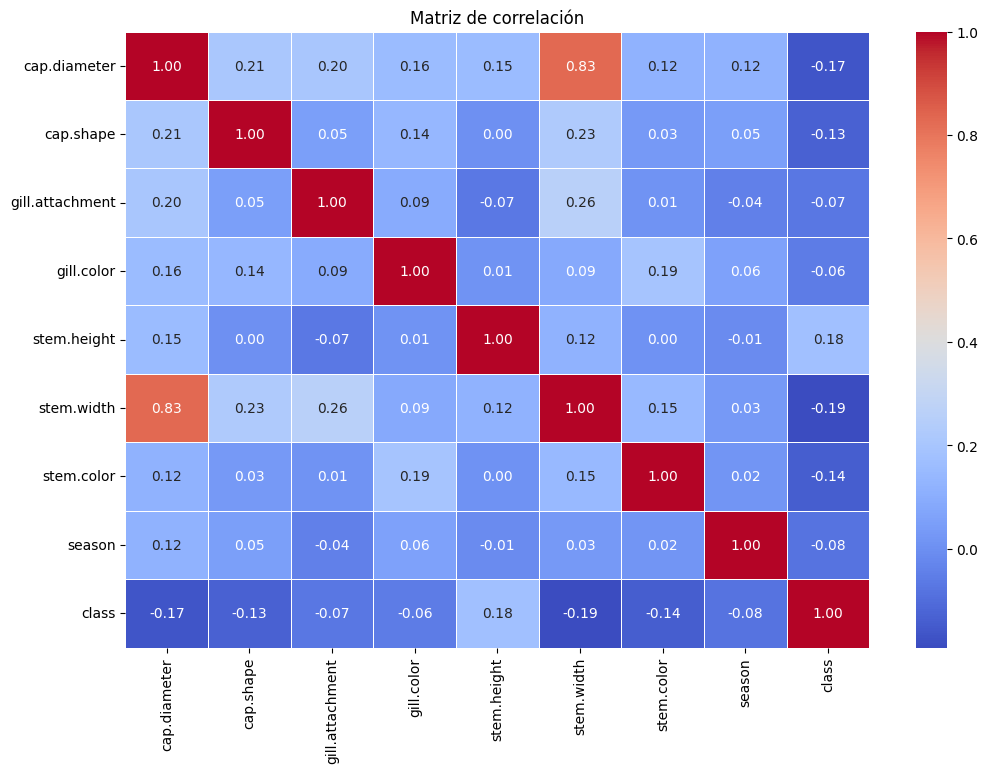

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo las columnas numéricas
numeric_data = data.select_dtypes(include=['float64', 'int64'])

# Calcular la matriz de correlación
cor_matrix = numeric_data.corr()

# Crear un gráfico de correlación usando seaborn
plt.figure(figsize=(12, 8))
sns.heatmap(cor_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Ajustar el título y mostrar el gráfico
plt.title("Matriz de correlación")
plt.show()

plt.savefig("matriz_correlacion.jpg")  

La matriz de correlación nos permite ver, que en general, no parece que haya una correlación significativa entre los datos, excepto entre stem.width y cap.diameter, pero en un sentido biológico, es lógico pensar que el diámetro del sombrero del hongo y el grosor del tallo están positivamente relacionados.

Vimos, en el análisis preeliminar, que los datos parecen ser todos de categoría numérica, pero esta información no es del todo correcta. De hecho, gracias al contexto biológico podemos determinar que, pese a que la variable cap.shape (por ejemplo) nos indica unos valores numéricos, realmente cada valor nos indica una variable categórica. Del mismo modo, las variables gill.attachment, gill.color y stem.color han resultado categóricas.

Por ende, las redes neuronales artificiales no podrá determinar realmente si, en caso de emplear esta característica para tomar decisiones serían incorrectas. Un método habitual de codificación es el One-hot encoding, de manera que se cree una matriz de datos en que se determine una presencia con "1" y ausencia con "0".

Para poder codificar las variables, crearemos una nueva función `codification`, que con el input del data set y la variable, cree una matriz de datos con la columna dividida en diferentes columnas codificadas.

In [ ]:
def codification(data, column_name):
    # Aplicar One-Hot Encoding usando pd.get_dummies
    one_hot = pd.get_dummies(data[column_name], prefix=column_name)

    # Convertir los valores booleanos a enteros (0 y 1)
    one_hot = one_hot.astype(int)

    # Eliminar la columna original
    data = data.drop(column_name, axis=1)

    # Añadir las nuevas columnas codificadas al DataFrame
    data = pd.concat([data, one_hot], axis=1)

    return data

Ahora que hemos generado la función que nos permita realizar la codificación, aplicaremos este método a todas las variables que hemos considerado categóricas.

In [ ]:
columns_to_encode = ['cap.shape', 'gill.attachment', 'gill.color', 'stem.color']

# Iterar y aplicar la función codification a cada columna
for column in columns_to_encode:
    data = codification(data, column)

data.head()

,cap.diameter,stem.height,stem.width,season,class,cap.shape_0,cap.shape_1,cap.shape_2,cap.shape_3,cap.shape_4,...,stem.color_3,stem.color_4,stem.color_5,stem.color_6,stem.color_7,stem.color_8,stem.color_9,stem.color_10,stem.color_11,stem.color_12
0,346,1.504484,392,0.888450,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
1,319,0.207333,343,0.943195,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
2,540,0.099900,459,0.943195,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,491,0.469946,1876,0.027372,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,485,0.442093,651,0.943195,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


Las variables numéricas, gracias a `.describe()`, podemos ver que tienen un gran rango, y por lo tanto, afectarán al aprendizaje de los datos. Por lo tanto debemos normalizar los datos de alguna manera. Un método habitual de normalización es el escalado minmax, en que se establecen los datos en un rango especifico, de 0 a 1.

Primero, generaremos la función para el escalado (`normalize_minmax()`), para posteriormente aplicarlo a las variables numéricas.

In [ ]:
def normalize_minmax(data, column):
    data[column] = (data[column] - data[column].min()) / (data[column].max() - data[column].min())
    return data

columns_to_scale = ['cap.diameter', 'stem.height', 'stem.width', 'season']

# Iterar y aplicar la función codification a cada columna
for column in columns_to_scale:
    data = normalize_minmax(data, column)

data.describe()

,cap.diameter,stem.height,stem.width,season,class,cap.shape_0,cap.shape_1,cap.shape_2,cap.shape_3,cap.shape_4,...,stem.color_3,stem.color_4,stem.color_5,stem.color_6,stem.color_7,stem.color_8,stem.color_9,stem.color_10,stem.color_11,stem.color_12
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.00000,10000.000000,10000.00000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,0.301385,0.198391,0.295940,0.521607,0.549000,0.094900,0.032600,0.228300,0.048200,0.031900,...,0.048600,0.009800,0.00350,0.280500,0.03570,0.017800,0.00990,0.025800,0.379400,0.130900
std,0.191135,0.171822,0.220619,0.171013,0.497618,0.293091,0.177596,0.419758,0.214199,0.175743,...,0.215041,0.098514,0.05906,0.449266,0.18555,0.132231,0.09901,0.158546,0.485262,0.337308
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,0.153999,0.070333,0.116839,0.484596,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,0.277542,0.155636,0.258616,0.515404,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,0.415784,0.274957,0.428411,0.515404,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,1.000000,0.00000,0.000000,0.00000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,1.00000,1.000000,1.000000,1.000000


Ahora que hemos cargado los datos y los hemos analizado y transformado,debemos establecer una nueva semilla para poder asegurar la reproducibilidad de los datos.

Para poder crear el algoritmo, entrenarlo y posteriormente evaluarlo, tenemos que dividir el dataset original en dos grupos, un grupo de entrenamiento con el 75% de los datos, y un grupo de prueba con el 25% restante.

El paquete numpy contiene una función `.random.seed()` que nos permite establecer la semilla aleatoria, para posteriormente obtener indices randomizados gracias a la función `np.random.choice()` y, con los índices, generar lso grupos de entrenamiento y prueba.

Para verificar que se ha creado correctamente, imprimiremos las dimensiones de los grupos, para asegurarnos de que no hemos perdido variables o registros.

In [ ]:
import numpy as np
# Establecer la semilla
np.random.seed(12345)


# Dividir el dataset en 75% entrenamiento y 25% prueba
train_indices = np.random.choice(data.index, size=int(3/4 * len(data)), replace=False)
train_data = data.loc[train_indices]
test_data = data.drop(train_indices)

print(train_data.shape)
print(test_data.shape)

(7500, 44)
(2500, 44)


Podemos decir, entonces, que los datos se han dividido correctamente en base a las dimensiones de los dos nuevos dataset. Es importante que, para que los grupos representen al dataset original, debemos asegurarnos de que la variable objetivo mantenga las proporciones en ambos grupos.

In [ ]:
print("Proporción de clases en todo el conjunto de datos:")
print(data['class'].value_counts(normalize=True))

print("\nProporción de clases en el conjunto de entrenamiento:")
print(train_data['class'].value_counts(normalize=True))

print("\nProporción de clases en el conjunto de prueba:")
print(test_data['class'].value_counts(normalize=True))

Proporción de clases en todo el conjunto de datos:
class
1    0.549
0    0.451
Name: proportion, dtype: float64

Proporción de clases en el conjunto de entrenamiento:
class
1    0.5448
0    0.4552
Name: proportion, dtype: float64

Proporción de clases en el conjunto de prueba:
class
1    0.5616
0    0.4384
Name: proportion, dtype: float64


En ambos grupos, las proporciones son relativamente parecidas a los del grupo original, por lo que podemos afirmar que la división ha sido satisfactoria.

## Creación del algoritmo

De las bibliotecas disponibles capaces de generar redes neuronales, tensorflow es especialmente flexible y capaz de trabajar con datos complejos, incluyendo imágenes o texto. Dentro de tensorflow, keras permite simplificar la construcción y entrenamiento de los modelos, mientras que `sklearn.metrics` nos proporciona los resultados de la evaluación mediante una matriz de confusión (como el paquete caret en R).

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout

La creación de algoritmos de ANN requiere de la comprensión y estalbecimiento de ciertos parámetros, los cuales determinarán la capacidad del algoritmo de procesar los datos proporcionados.

Mencionamos anteriormente que las ANN simulan el funcionamiento del cerebro humano. De ese modo, las ANN están configuradas como capas de neuronas conectadas entre ellas, desde la entrada de los datos, hasta los valores de salida. En función de las conexiones, las neuronas se pueden clasificar en tipos como densas (conectadas a todas las neuronas de la siguiente capa) o de convolución (conectadas a un subconjunto de neuronas de la capa anterior), entre otras.

Además, debemos tener en cuenta que las neuronas pueden ser activadas mediante diferentes funciones de activación, que realizan transformaciones no lineales aplicadas al resultado de la capa antes de pasarlo a la siguiente. Estas funciones permiten, por lo tanto, que la red neuronal aprenda relaciones complejas y aumenta su capacidad de modelado. Existen múltiples tipos de funciones de activación, pero las más comunes son la función ReLU (convierte valores negativos a 0), la función sigmoide (convierte los valores de un rango 0-1) y la función softmax (convierte los valores en probabilidades de total igual a 1).

Finalmente, los algoritmos necesitan de *optimizadores*, que ajustarán los pesos de la red neuronal durante el entrenamiento para que, durante el entrenamiento, minimizar la función de pérdida. De esta manera, la red aprende correctamente ajustando los pesos en cada iteración, mejorando cada vez. Existen tipos diversos de optimizadores, entre los que se encuentran el Gradiente Descediente Estocástico (usa gradientes calculados en pequeñas muestras de datos) y ADAM (combina SGD y métodos de gradientes acumulados).

Para poder crear la red neuronal, usaremos la función `Sequential()`, seguidas de las diferentes capas de neuronas. Debido a la naturaleza de nuestros datos, crearemos un modelo de 2 capas, una capa densa con activación ReLU y una capa densa de salida con activación sigmoide. Esta es una configuración simple para datos binarios (como es nuestro caso, debido a la clase objetivo). Como mecanismo preventivo ante el sobreajuste, añadiremos una capa de Dropout, que inactivará un porcentaje determinado de neuronas en cada época del aprendizaje.


In [ ]:
# Definir la dimensión de entrada
input_dim = train_data.shape[1] - 1  # Ajustar según tus datos de entrada

# Crear el modelo secuencial
model1 = Sequential()
model1.add(Dense(8, activation='relu', input_shape=(input_dim,)))
model1.add(Dropout(0.5))
model1.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Una vez diseñada la red, se debe compilar el modelo con el optimizador, y debemos especificar con qué metrica se va a evaluar el rendimiento del modelo (precisión). Para visualizar el resultado del modelo, podemos emplear la función `summary()` sobre el modelo.

In [ ]:
# Compilar el modelo
model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model1.summary(line_length=60)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape      ┃   Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ dense (Dense)            │ (None, 8)         │       352 │
├──────────────────────────┼───────────────────┼───────────┤
│ dropout (Dropout)        │ (None, 8)         │         0 │
├──────────────────────────┼───────────────────┼───────────┤
│ dense_1 (Dense)          │ (None, 1)         │         9 │
└──────────────────────────┴───────────────────┴───────────┘

 Total params: 361 (1.41 KB)

 Trainable params: 361 (1.41 KB)

 Non-trainable params: 0 (0.00 B)

Vemos, entonces, que tenemos 3 capas de neuronas, y la columna Param nos indica los parámetros que se aprenderan en cada capa de la red.

Hasta el momento, no hemos entrenado el modelo con los datos, solo lo hemos diseñado para que pueda procesar los datos según su estructura. Para poder entrenarlo, debemos recurrira a la función `.drop()`, en que se introduce el conjunto de datos de entrenamiento, la clase objetivo y la cantidad de épocas que ejecutará la red.

Un aspecto no mencionado anteriormente, pero igual de relevante en las redes neuronales artificiales es el efecto del batch, que es el tamaño de los lotes en que se dividirá el conjunto de datos de entrenamiento pre-evaluación de los pesos, y el *validation_split*, que especificará el porcentaje del conjunto de datos de entrenamiento que se usará como validación.

In [ ]:
# Preparar los datos de entrenamiento
X_train = train_data.drop('class', axis=1).values  # Excluir la columna 'Uva'
y_train = pd.factorize(train_data['class'])[0]  # Convertir 'Uva' en valores numéricos (0-indexed)


# Entrenar el modelo
history_1 = model1.fit(train_data.drop('class', axis=1),
                       train_data['class'],
                        epochs=100,
                        batch_size=32,
                        validation_split=0.2,
                        verbose=0)


Para poder visualizar el proceso de entrenamiento del modelo, crearemos un gráfico de evolución tanto del entrenamiento como la función de pérdida. En estos gráficos veremos como, en cada época, la red ha evolucionado y si el aprendizaje se ha visto mejorado o, en caso de que se sufra sobreajuste, el entrenamiento se vea estancado.

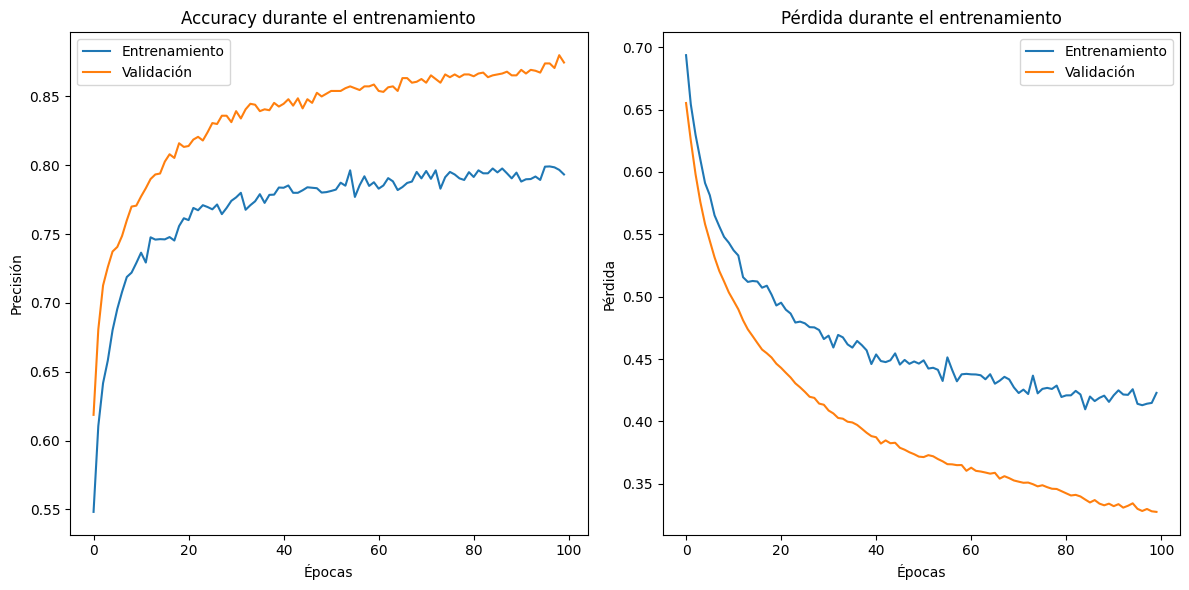

In [ ]:
# Graficar la precisión
plt.figure(figsize=(12, 6))

# Gráfico de accuracy
plt.subplot(1, 2, 1)
plt.plot(history_1.history['accuracy'], label='Entrenamiento')
plt.plot(history_1.history['val_accuracy'], label='Validación')
plt.title('Accuracy durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# Gráfico de pérdida
plt.subplot(1, 2, 2)
plt.plot(history_1.history['loss'], label='Entrenamiento')
plt.plot(history_1.history['val_loss'], label='Validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

El gráfico de precisión fluctua un poco (pero podría ser debido al batch), la precisión de validación es bastante más estable, y de hecho se atasca en un valor relativamente alto. Esta estabilidad frente a la variabilidad del entrenamiento podría ser consecuencia del dropout, que ayuda a regularizar el modelo.

Respecto al gráfico de pérdida, tanto el entrenamiento como la validación desciende constantemente, indicando que está aprendiendo y no hay un aparente sobreajuste. La pérdida de validación es más suave y estable que el entrenamiento, lo cual es una buena señal.

Podríamos decir que el dropout funciona como regularización, ya que no hay un sobreajuste a los datos de entrenamiento, y se mantiene un aprendizaje estable.

##  Evaluación del modelo

Hasta el momento, hemos comprobado como funciona el modelo con los datos vistos (train_data), pero para verificar que el modelo tiene capacidad de generalizar su proceso a datos no vistos, tenemos que contraponer las predicciones resultantes del modelo con verdaderos datos no vistos anteriormente.

Por lo tanto, usaremos las características de test_data para obtener sus predicciones, y evaluaremos el rendimiento del modelo mediante una matriz de confusión. De este modo, obtendremos los valores de class reales vs los valores predichos.

Para empezar, visualizaremos los valores de loss y accuracy mediante la función `evaluate()`

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Evaluar el modelo en los datos de prueba
loss, accuracy = model1.evaluate(test_data.drop('class', axis=1), test_data['class'])
print(f'Modelo 2 (2 capas ocultas) - Pérdida: {loss}, Precisión: {accuracy}')

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8845 - loss: 0.3195
Modelo 2 (2 capas ocultas) - Pérdida: 0.318103551864624, Precisión: 0.881600022315979


Entonces, en el modelo de 2 capas (una densa, y una de salida) hemos obtenido una precisión del 89.78% y una pérdida del 30.81%.

Seguidamente, realizaremos las predicciones, especificando 'int32' para que las predicciones sigan una clasificación binaria, y contrapondremos los datos predichos vs reales. Para hacer más visual el resultado de la matriz de confusión, usaremos un heatmap

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


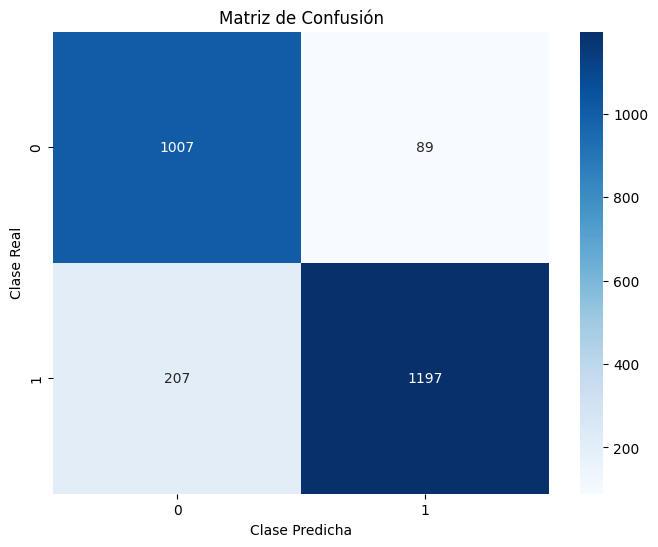

In [ ]:
#obtener datos de test_data
X_test = test_data.drop('class', axis=1).values  # Excluir la columna 'Uva'
y_test = pd.factorize(test_data['class'])[0]  # Convertir 'Uva' en valores numéricos (0-indexed)



# Hacer predicciones en los datos de prueba
predictions = model1.predict(test_data.drop('class', axis=1))
predictions = (predictions > 0.5).astype('int32')  # Umbral de 0.5 para clasificación binaria

# Matriz de confusión
cm = confusion_matrix(test_data['class'], predictions)

# Graficar la matriz de confusión con un mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.title('Matriz de Confusión')
plt.show()


Entonces, podemos ver que tenemos 1015 VP y 1220 VN, que en una muestra de 2500 registros, son valores bastante buenos. Para poder obtener el rendimiento del modelo, calcularemos  

In [ ]:
# Sensibilidad (Recall) y Especificidad
sensitivity = cm[1, 1] / (cm[1, 0] + cm[1, 1])  # Verdaderos positivos / (Verdaderos positivos + Falsos negativos)
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])  # Verdaderos negativos / (Verdaderos negativos + Falsos positivos)
accuracy = cm[1, 1] / (cm[1, 1] + cm[0, 1])

# Mostrar la sensibilidad y especificidad
print(f"Sensibilidad: {sensitivity:.4f}")
print(f"Especificidad: {specificity:.4f}")
print(f"Precisión: {accuracy:.4f}")

Sensibilidad: 0.8526
Especificidad: 0.9188
Precisión: 0.9308


Vemos, por lo tanto, que en general tenemos un rendimiento bastante bueno, con una precisión del 86,89%, una especificidad del 92,61% y una precisión general del 93,77%.

Son muy buenos valores, y podemos decir que el modelo de red neuronal artificial de 2 neuronas es muy eficiente en la clasificación de hongos con las características que hemos proporcionado.

##  Mejorando el modelo

Como todos los algoritmos de clasificación, las ANN tienen opciones y mecanismos de mejora del rendimiento. Como hemos mencionado antes, las redes ANN tienen una configuración bastante compleja, pero la manera más simple de mejora suele ser añadir más capas neuronales en el modelo.

Este mecanismo tiene sus ventajas, ya que permite aprender relaciones no lineales y complejas en los datos, así como construir representaciones jerárquicas de los datos. Aún así, más capas implica también más parámetros, lo que puede llevar a un sobreajuste problemático a los datos de entrenamiento. Además, también tendrá un mayor coste computacional, y hasta podría afectar a los gradientes hasta volverlos extremadamente pequeños (vanishing).

Para mejorar el modelo anterior, añadiremos una sola capa densa de 10 nodos, con una capa de dropout para tratar de regularizar el sobreajuste.

In [ ]:
# Crear el modelo con dos capas ocultas de 10 nodos
model2 = Sequential()
model2.add(Dense(10, activation='relu', input_shape=(train_data.shape[1] - 1,)))  # Capa de entrada + primera capa oculta
model2.add(Dropout(0.5))
model2.add(Dense(10, activation='relu'))  # Segunda capa oculta
model2.add(Dropout(0.5))
model2.add(Dense(1, activation='sigmoid'))  # Capa de salida

model2.summary(line_length=60)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape      ┃   Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ dense_2 (Dense)          │ (None, 10)        │       440 │
├──────────────────────────┼───────────────────┼───────────┤
│ dropout_1 (Dropout)      │ (None, 10)        │         0 │
├──────────────────────────┼───────────────────┼───────────┤
│ dense_3 (Dense)          │ (None, 10)        │       110 │
├──────────────────────────┼───────────────────┼───────────┤
│ dropout_2 (Dropout)      │ (None, 10)        │         0 │
├──────────────────────────┼───────────────────┼───────────┤
│ dense_4 (Dense)          │ (None, 1)         │        11 │
└──────────────────────────┴───────────────────┴───────────┘

 Total params: 561 (2.19 KB)

 Trainable params: 561 (2.19 KB)

 Non-trainable params: 0 (0.00 B)

Este nuevo modelo tiene ahora 3 capas de aprendizaje y 2 capas de dropout, y los parámetros que se aprenden en cada capa son cada vez menores, lo que puede llevar a un aprendizaje más preciso.

Para evaluar este nuevo modelo, compilaremos con un optimizador ADAM y lo entrenaremos con los datos de entrenamiento

In [ ]:
# Compilar el modelo
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entrenar el modelo
history_2 = model2.fit(train_data.drop('class', axis=1),
                       train_data['class'],
                        epochs=100,
                        batch_size=32,
                        validation_split=0.2,
                        verbose=0)

Para poder evaluar la diferencia entre los dos modelos, contrapondremos los gráficos de la evolución de la función de pérdida y precisión en función de la época.

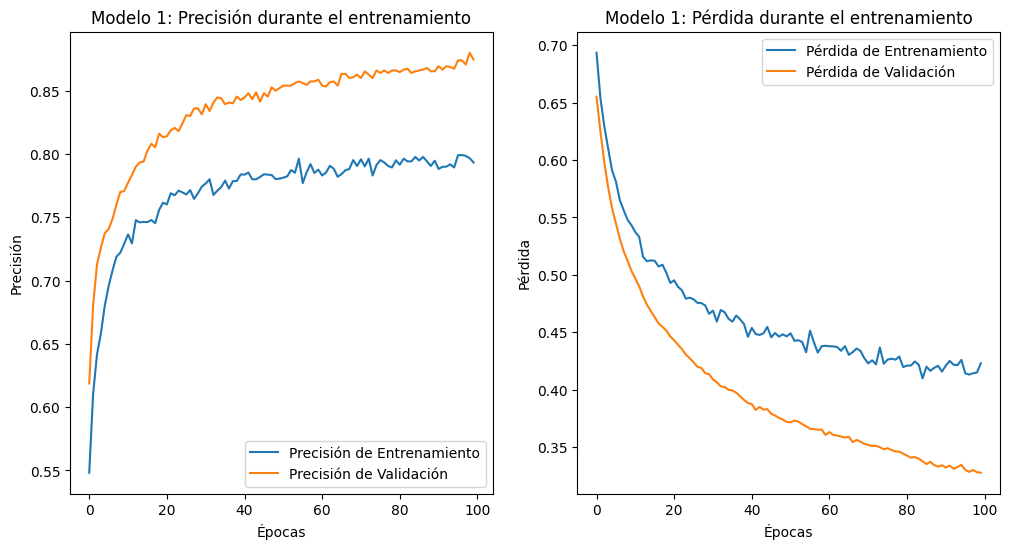

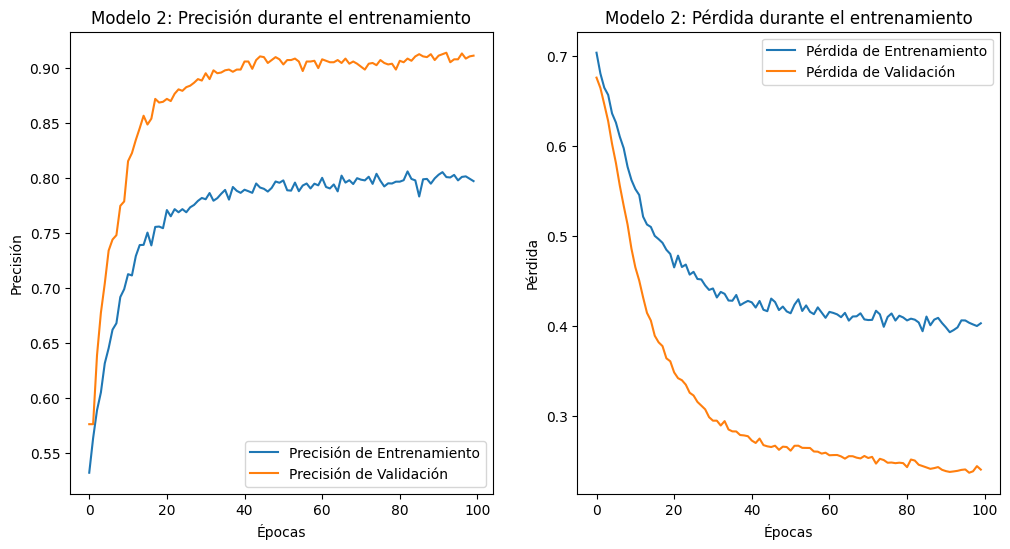

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9304 - loss: 0.2405
Modelo 2 (2 capas ocultas) - Pérdida: 0.23557953536510468, Precisión: 0.9251999855041504


In [ ]:
import matplotlib.pyplot as plt

# Graficar la precisión y la pérdida para el modelo 1
plt.figure(figsize=(12, 6))

# Precisión
plt.subplot(1, 2, 1)
plt.plot(history_1.history['accuracy'], label='Precisión de Entrenamiento')
plt.plot(history_1.history['val_accuracy'], label='Precisión de Validación')
plt.title('Modelo 1: Precisión durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(history_1.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history_1.history['val_loss'], label='Pérdida de Validación')
plt.title('Modelo 1: Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.show()

# Graficar la precisión y la pérdida para el modelo 2
plt.figure(figsize=(12, 6))

# Precisión
plt.subplot(1, 2, 1)
plt.plot(history_2.history['accuracy'], label='Precisión de Entrenamiento')
plt.plot(history_2.history['val_accuracy'], label='Precisión de Validación')
plt.title('Modelo 2: Precisión durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(history_2.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history_2.history['val_loss'], label='Pérdida de Validación')
plt.title('Modelo 2: Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.show()

# Evaluar el modelo en los datos de prueba
loss_2, accuracy_2 = model2.evaluate(test_data.drop('class', axis=1), test_data['class'])
print(f'Modelo 2 (2 capas ocultas) - Pérdida: {loss_2}, Precisión: {accuracy_2}')


Gracias a los gráficos, podemos afirmar que la distancia entre la precisión y la validación, así como el entrenamiento y la validación, se han visto reducidas. Esta diferencia nos indica que, el nuevo modelo, parece estar aprendiendo mejor como es la relación entre los datos. Además, los valores de precisión y pérdida son ligeramente mejores que en el modelo anterior.

Para poder evaluar realmente el rendimiento del nuevo modelo, obtendremos los valores de sensibilidad, especificidad y precisión.

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Matriz de confusión del Modelo 2:
[[ 984  112]
 [  75 1329]]
Sensibilidad: 0.9466
Especificidad: 0.8978
Precisión: 0.9252


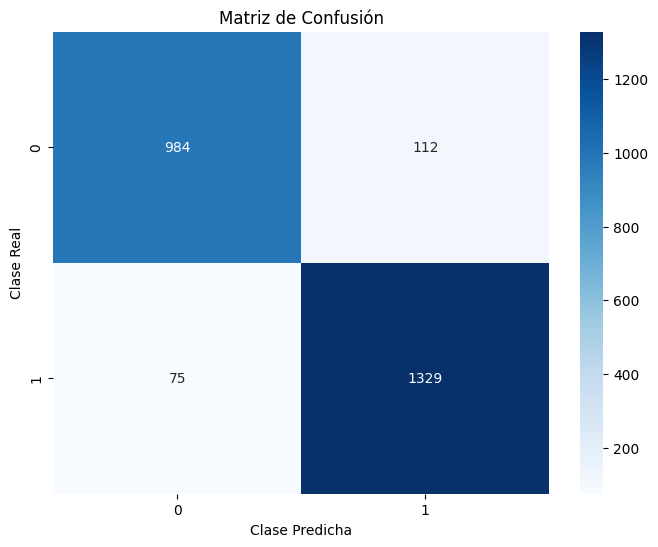

In [ ]:
# Hacer predicciones en los datos de prueba
predictions_2 = model2.predict(test_data.drop('class', axis=1))
predictions_2 = (predictions_2 > 0.5).astype('int32')

# Matriz de confusión
cm_2 = confusion_matrix(test_data['class'], predictions_2)
print(f'Matriz de confusión del Modelo 2:\n{cm_2}')

# Sensibilidad (Recall) y Especificidad
sensitivity_2 = cm_2[1, 1] / (cm_2[1, 0] + cm_2[1, 1])
specificity_2 = cm_2[0, 0] / (cm_2[0, 0] + cm_2[0, 1])
accuracy_2 = (cm_2[1, 1] + cm_2[0, 0]) / cm_2.sum()

# Mostrar la sensibilidad y especificidad
print(f"Sensibilidad: {sensitivity_2:.4f}")
print(f"Especificidad: {specificity_2:.4f}")
print(f"Precisión: {accuracy_2:.4f}")

# Graficar la matriz de confusión con un mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.title('Matriz de Confusión')
plt.show()


Pese a ampliar la red neuronal con una capa neuronal densa, vemos que la precisión ha descendido desde un 93,77% a un 85,92%, por lo que el añadir una capa más no solo no ha mejorado su rendimiento, si no que todo lo contrario.  Respecto a la sensibilidad, también ha descendido a un 77,99%, pero la especificidad, en cambio, ha incrementado hasta un 96,08%.

Sabemos que, el añadir más capas y nodos puede hacer el modelo más flexible y capaz de captar relaciones complejas, pero en nuestro modelo, el hecho de añadirlas parece sobreajustarse a los datos de entrenamiento. Esto puede ser porque los modelos más complejos requieren más datos para entrenarse correctamente sin sobreajustarse.

Debemos, debido a nuestros datos, decantarnos más por el diseño más simple, el cual ha obtenido un mejor rendimiento en general.